Dataset: https://www.kaggle.com/datasets/abcsds/pokemon

In [94]:
import pandas as pd
import math
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

# Read the Dataset
df = pd.read_csv("Pokemon.csv")
df2 = pd.read_csv("LoL_champions_encoded.csv")

# Get 100 random pokemon
sample = df.sample(n=100, random_state=42)
sample.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
696,635,Hydreigon,Dark,Dragon,600,92,105,90,125,90,98,5,False
667,606,Beheeyem,Psychic,NaN,485,75,75,75,125,95,40,5,False
63,58,Growlithe,Fire,NaN,350,55,70,45,70,50,60,1,False
533,479,RotomWash Rotom,Electric,Water,520,50,65,107,105,107,86,4,False
66,61,Poliwhirl,Water,NaN,385,65,65,65,50,50,90,1,False


In [95]:
# All pokemon types
all_types = [
    "Normal", "Fire", "Fighting", "Water", "Flying", "Grass",
    "Poison", "Electric", "Ground", "Psychic", "Rock", "Ice",
    "Bug", "Dragon", "Ghost", "Dark", "Steel", "Fairy"  
    ]

# Basically one hot encoding
for t in all_types:
    sample[t] = ((sample["Type 1"] == t) | (sample["Type 2"] == t)).astype(int)

In [96]:
# Get the stat features
stats_col = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]

# All features we want
feature_col = stats_col + all_types

# Getting the values we want
features = sample[feature_col].values

# Min max norm
col_min = features.min(axis=0)
col_max = features.max(axis=0)
col_range = col_max - col_min
feature_norm = (features - col_min) / col_range

# Get the names of the pokemon
names = sample["Name"].tolist()

# Incase we want to change the sample size
n = len(feature_norm)

# Just to see what we are working with
df_norm = pd.DataFrame(feature_norm, columns=feature_col, index=names)
df_norm.head()

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Normal,Fire,Fighting,Water,...,Ground,Psychic,Rock,Ice,Bug,Dragon,Ghost,Dark,Steel,Fairy
Hydreigon,0.496552,0.633333,0.282051,0.676471,0.500000,0.628571,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
Beheeyem,0.379310,0.433333,0.205128,0.676471,0.535714,0.214286,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Growlithe,0.241379,0.400000,0.051282,0.352941,0.214286,0.357143,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
RotomWash Rotom,0.206897,0.366667,0.369231,0.558824,0.621429,0.542857,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Poliwhirl,0.310345,0.366667,0.153846,0.235294,0.214286,0.571429,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [97]:
# Set up distance matrix and make it all 0
distance_matrix = [[0.0 for _ in range(n)] for _ in range(n)]

# Calculating distances
for i in range(n):
    for j in range(i+1, n):
        diff = feature_norm[i] - feature_norm[j]
        distance = math.sqrt((diff ** 2).sum())
        distance_matrix[i][j] = distance
        distance_matrix[j][i] = distance

<function matplotlib.pyplot.show(close=None, block=None)>

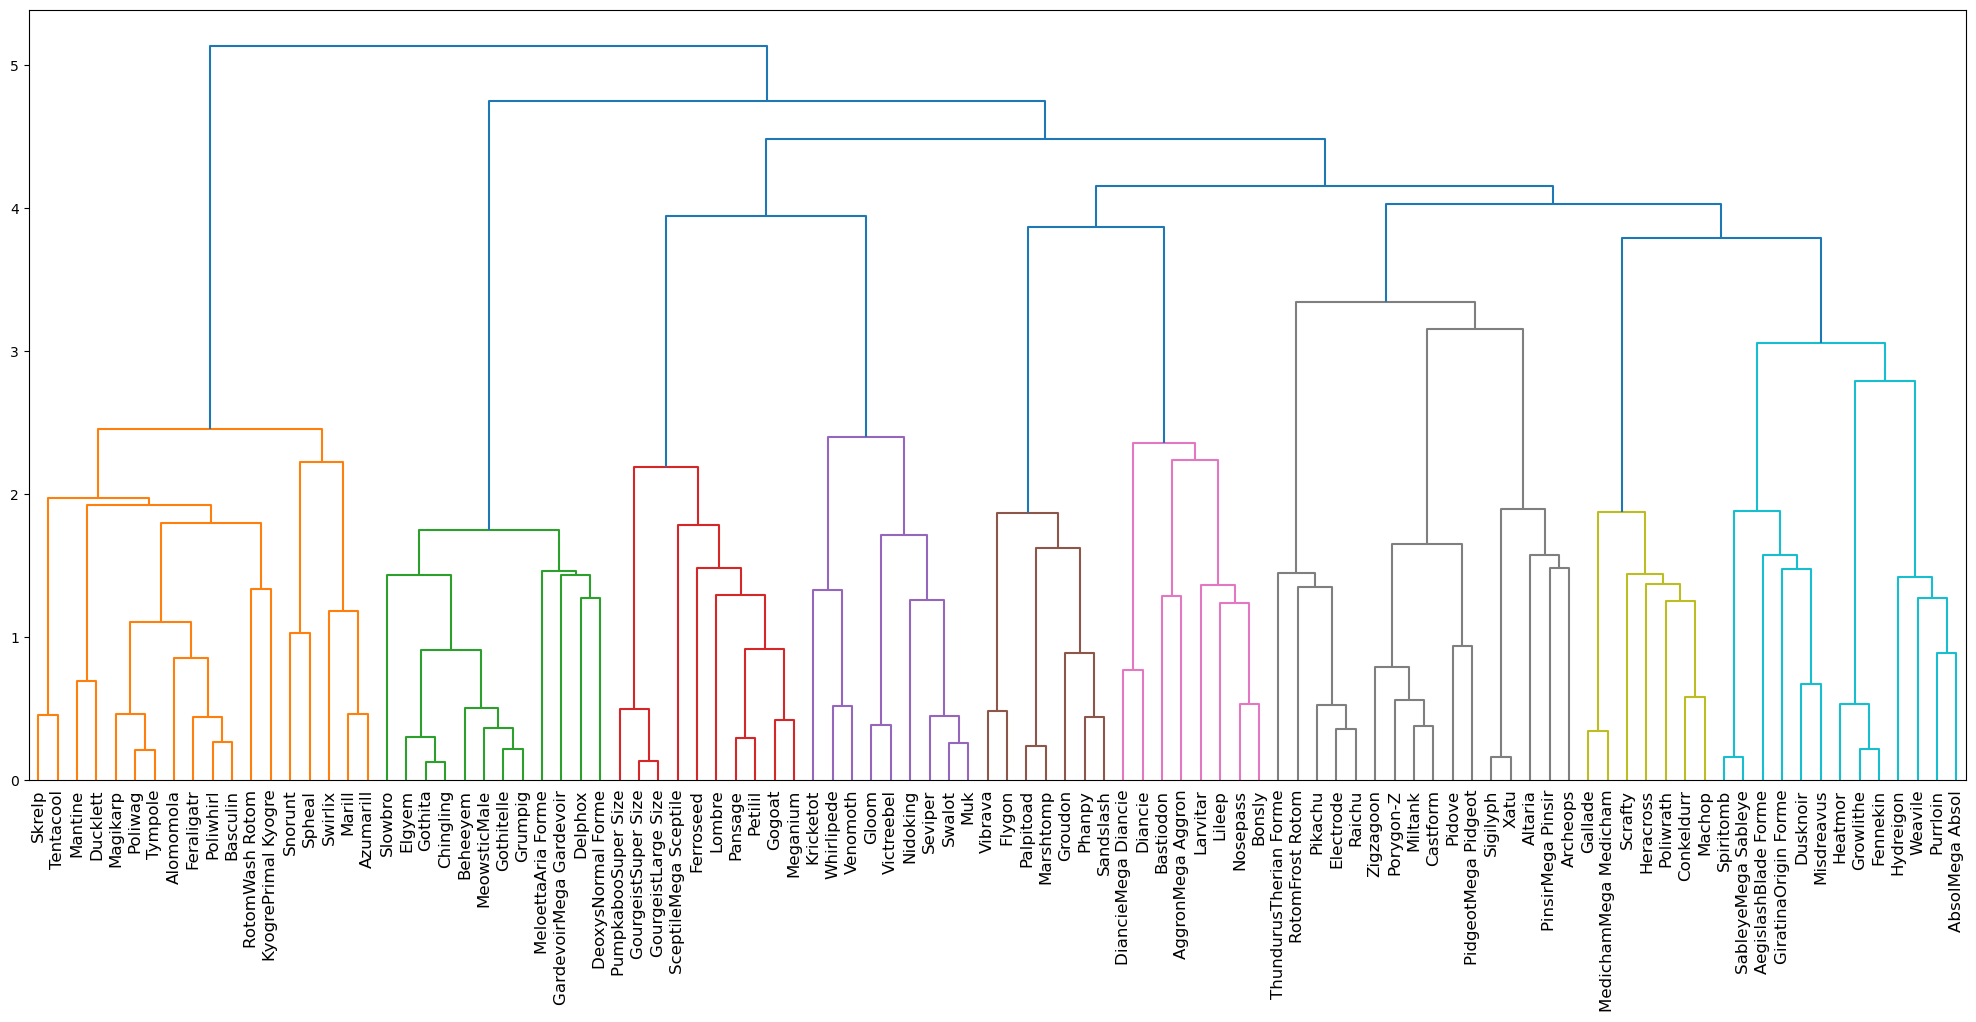

In [106]:
# Getting the dendrogram
# https://stackoverflow.com/questions/41416498/dendrogram-or-other-plot-from-distance-matrix
dists = squareform(distance_matrix)
linkage_matrix = linkage(dists, "ward")
plt.figure(figsize=(25, 10))
dendrogram(
    linkage_matrix,
    labels=names,
    leaf_font_size=12
)
plt.show

In [99]:
features_col2 = [
    "Role_Top", "Role_Jungle", "Role_Middle", "Role_Bottom", "Role_Support", "Tag_Assassin",
    "Tag_Fighter", "Tag_Mage", "Tag_Marksman", "Tag_Support", "Tag_Tank", "Is_Ranged",
    "Res_Mana", "Res_Energy", "Res_Other", "Base HP", "HP per lvl", "Base mana",
    "Mana per lvl", "Movement speed", "Base armor", "Armor per lvl", "Base magic resistance", "Magic resistance per lvl",
    "Attack range", "HP regeneration", "HP regeneration per lvl", "Mana regeneration", "Mana regeneration per lvl", "Attack damage",
    "Attack damage per lvl", "Attack speed per lvl", "Attack speed", "AS ratio"
]

# Get feature values
features2 = df2[features_col2].values

# Min max norm for df 2
col_min2 = features2.min(axis=0)
col_max2 = features2.max(axis=0)
col_range2 = col_max2 - col_min2
feature_norm2 = (features2 - col_min2) / col_range2

# Get names
names2 = df2["Name"].tolist()

# Incase we want to change the sample size
n2 = len(feature_norm2)

# Just to see what we are working with
df_norm2 = pd.DataFrame(feature_norm2, columns=features_col2, index=names2)
df_norm2.head()

,Role_Top,Role_Jungle,Role_Middle,Role_Bottom,Role_Support,Tag_Assassin,Tag_Fighter,Tag_Mage,Tag_Marksman,Tag_Support,...,Attack range,HP regeneration,HP regeneration per lvl,Mana regeneration,Mana regeneration per lvl,Attack damage,Attack damage per lvl,Attack speed per lvl,Attack speed,AS ratio
Aatrox,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.095238,0.300,0.40,0.000,0.0,0.64,1.00,0.416667,0.469333,0.765882
Ahri,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.809524,0.250,0.48,0.160,0.8,0.36,0.60,0.366667,0.514667,0.735294
Akali,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.000000,0.900,0.72,1.000,0.0,0.72,0.66,0.533333,0.400000,0.735294
Akshan,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.714286,0.375,0.52,0.164,0.7,0.32,0.60,0.666667,0.434667,0.470588
Alistar,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.000000,0.850,0.68,0.170,0.8,0.72,0.75,0.354167,0.400000,0.735294


In [102]:
# Set up distance matrix and make it all 0
distance_matrix2 = [[0.0 for _ in range(n2)] for _ in range(n2)]

# Calculating distances
for i in range(n2):
    for j in range(i+1, n2):
        diff = feature_norm2[i] - feature_norm2[j]
        distance = math.sqrt((diff ** 2).sum())
        distance_matrix2[i][j] = distance
        distance_matrix2[j][i] = distance

<function matplotlib.pyplot.show(close=None, block=None)>

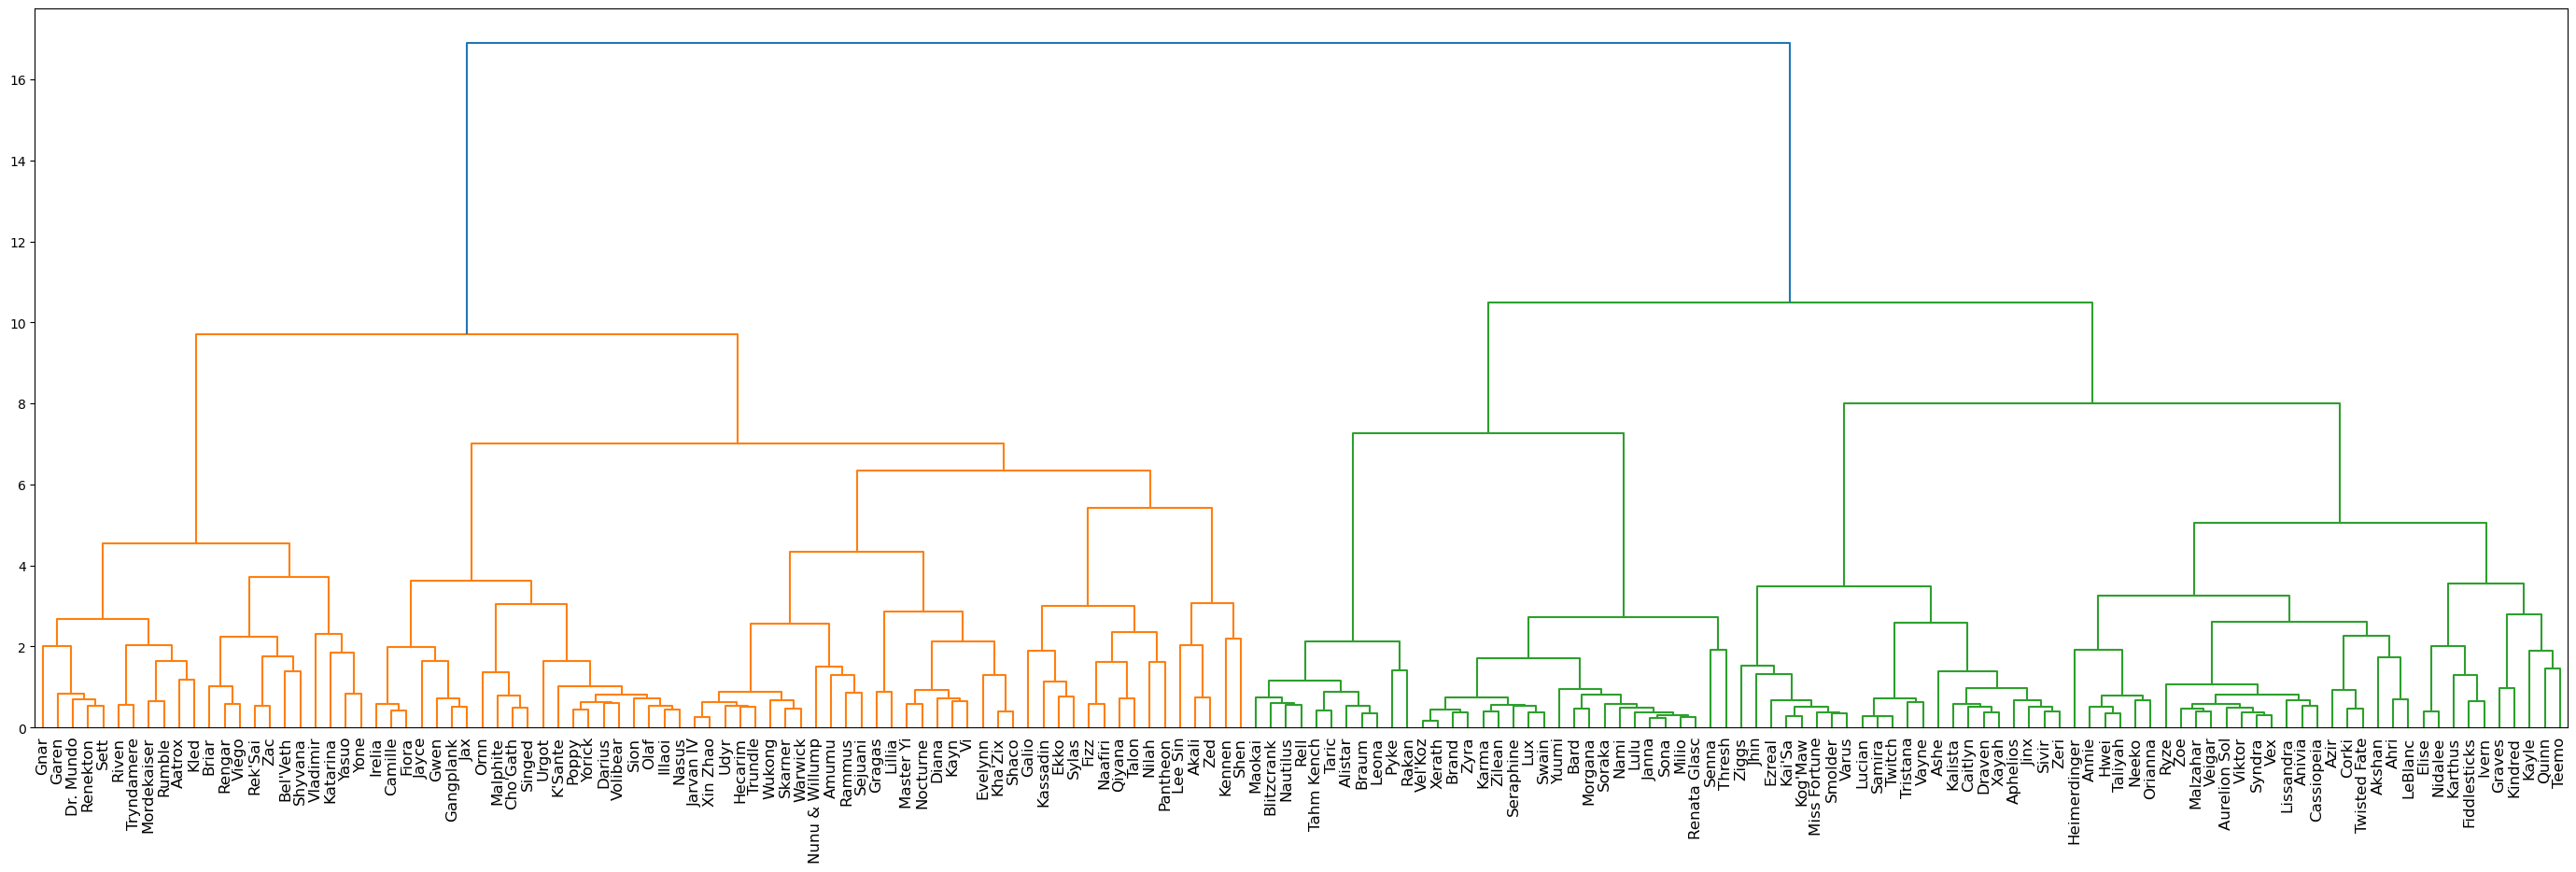

In [107]:
dists2 = squareform(distance_matrix2)
linkage_matrix2 = linkage(dists2, "ward")
plt.figure(figsize=(35, 10))
dendrogram(
    linkage_matrix2,
    labels=names2,
    leaf_font_size=12
)
plt.show